# Formalia

Please read the [assignment overview page](https://laura.alessandretti.com/comsocsci2026/wiki_pages/Assignments.html) carefully before proceeding. The page contains information about formatting (including formats etc), group sizes, and many other aspects of handing in the assignment. 

__If you fail to follow these simple instructions, it will negatively impact your grade!__

**Due date and time**: The assignment is due on Apr 7th at 23:59. Hand in your Jupyter notebook file (with extension `.ipynb`) via DTU Learn _(Assignment 2)_. 

Remember to include in the first cell of your notebook:
* the link to your group's Git repository 
* group members' contributions

In [12]:
import pandas as pd
import ast
from itertools import combinations
from collections import defaultdict
import networkx as nx
import numpy as np
import json

# Part 1: Mixing Patterns and Assortativity

> __Exercise 1: Mixing Patterns and Assortativity__  
>
> __Part 1: Assortativity Coefficient__ 
> 1. *Calculate the Assortativity Coefficient* for the network based on the country of each node. Implement the calculation using the formula provided during the lecture, also available in [this paper](https://arxiv.org/pdf/cond-mat/0209450.pdf) (equation 2, here for directed networks). **Do not use the NetworkX implementation.**
>

Firstly, we need to make a network. We use the provided dataset to make avoid running into unnecessay issues.


In [13]:
# load data
CSS_authors=pd.read_csv('data/final_authors.csv')
CSS_papers=pd.read_csv('data/final_papers.csv')
pair_counts=defaultdict(int)

In [54]:
# Compute all pairs of authors, who have published a paper together and count how many times they have
i=0
for authors in CSS_papers['author_ids'].apply(ast.literal_eval):
    for pair in combinations(authors,2):
        if None in pair:
            continue
        pair=tuple(sorted(pair))
        pair_counts[pair]+=1
    i+=1


In [55]:
our_authors=list(CSS_authors['id'].astype(str))

ohno=0

weighted_list=[]
for authors,number in pair_counts.items():
    author1,author2=authors
    # check if authors actually in our authors dataset
    if author1 not in our_authors: 
        ohno+=1
        continue
    if author2 not in our_authors: 
        ohno+=1
        continue
    weighted_list.append((author1,author2,number))

print(ohno)
print(len(weighted_list))

990184
51565


HVAD ER OHNO????? Burde nok beskrive hvad den printer

Now we create the graph, edges and country code data

In [56]:
G=nx.Graph()
G.add_weighted_edges_from(weighted_list)

import json
# set node attributes
for i,author_id in enumerate(G.nodes):        
    G.nodes[author_id]['country_code']=CSS_authors['country_code'][i]
    G.nodes[author_id]['display_name']=CSS_authors['display_name'][i]

# save network
JSON_data=nx.node_link_data(G)
with open('graph.json','w') as file:
    json.dump(JSON_data,file,indent=2)


Now that we have saved the graph, we can just load it to prevent having to make a new graph again:

In [2]:
# Load the network:
import json
import networkx as nx
with open(r"graph.json", 'r') as file:
    data = json.load(file)
G = nx.node_link_graph(data)

First we define a function to calculate the assortivity coefficient of the graph based on the country:

In [58]:
def compute_assortivity_country(G):
    e=defaultdict(int)
    a=defaultdict(int)
    # get all e and a values for each country code
    for edge in G.edges(data=True):
        n1=edge[0]
        n2=edge[1]
        country1=G.nodes[n1]['country_code']
        country2=G.nodes[n2]['country_code']
        if country1==country2:
            e[country1]+=1
        a[country1]+=1
        a[country2]+=1

    total_edges = G.number_of_edges()
    stubs=2*total_edges
    sum_e=sum(v/total_edges for v in e.values())
    sum_a=sum((v/stubs)**2 for v in a.values())
    r=(sum_e-sum_a)/(1-sum_a)
    
    print(f"The assortativity degree wrt. country is {r}")
    return r

Now we can calculate the assortativity degree of graph G

In [59]:
country_assortativity_G = compute_assortivity_country(G)

The assortativity degree wrt. country is 0.0018973173959750337


And the assortivity degree for this network is then 0.001897

> __Part 2: Configuration model__
> In the following, we are going to assess the significance of the assortativity by comparing the network's assortativity coefficient against that of random networks generated through the configuration model.  
>
> 2. *Implement the configuration model* using the _double edge swap_ algorithm to generate random networks. Ensure each node retains its original degree but with altered connections. Create a function that does that by following these steps:
>
>   - **a.** Create an exact copy of your original network.
>   - **b.** Select two edges, $e_{1} = (u,v)$ and $e_{2} = (x,y)$, ensuring *u != y* and *v != x*.
>   - **c.** Flip the direction of $e_{1}$ to $e_{1} = (v,u)$ 50% of the time. This ensure that your final results is not biased, in case your edges were sorted (they usually are). 
>   - **d.** Ensure that new edges $e_{1}' = (e_{1}[0],e_{2}[1])$ and $e_{2}' = (e_{2}[0],e_{1}[1])$ do not already exist in the network.
>   - **e.** Remove edges $e_{1}$ and $e_{2}$ and add edges $e_{1}'$ and $e_{2}'$.
>   - **f.** Repeat steps **b** to **e** until you have performed $E\cdot10$ swaps, where E is the total number of edges.
>

First we define a function to compute the edge swap

In [60]:
import random
def double_edge_swap(network,times=10):

    G_configuration = network.copy()
    edges = list(G_configuration.edges())  # build once

    num_edges = len(edges)

    for i in range(num_edges * times):

        # sample two edges uniformly
        (n1, n2) = random.choice(edges)
        (n3, n4) = random.choice(edges)

        # ensure the two edges are distinct
        if (n1, n2) == (n3, n4):
            continue

        # skip if they share a node
        if len({n1, n2, n3, n4}) < 4:
            continue

        # choose wiring pattern
        if random.random() < 0.5:
            a, b = n1, n3
            c, d = n2, n4
        else:
            a, b = n1, n4
            c, d = n2, n3

        # avoid self-loops and parallel edges
        if a == b or c == d:
            continue
        if G_configuration.has_edge(a, b) or G_configuration.has_edge(c, d):
            continue

        # perform swap
        G_configuration.remove_edge(n1, n2)
        G_configuration.remove_edge(n3, n4)
        G_configuration.add_edge(a, b)
        G_configuration.add_edge(c, d)

        # update the edges list incrementally
        edges.remove((n1, n2))
        edges.remove((n3, n4))
        edges.append((a, b))
        edges.append((c, d))
    return G_configuration

Then we can compute the configuration network. We compute 100 randomized random networks.

In [ ]:
from concurrent.futures import ThreadPoolExecutor
from tqdm.notebook import tqdm

# Generate at least 100 randomized networks
num_models = 2 #TODO : OBS ÆNDR TIL 100. DET HER ER FOR DEBUGGING !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

with ThreadPoolExecutor(max_workers=5) as executor:
    configs = list(tqdm(executor.map(double_edge_swap, [G] * num_models, [10] * num_models),total=num_models))

  0%|          | 0/2 [00:00<?, ?it/s]

The output from this is from tqdm, which cannot be rendered when uploaded to learn. It is simply a progress bar, which tells us how far we are in the process, as it is very computationally expensive to compute this. 

> 3. *Double check that your algorithm works well*, by showing that the degree of nodes in the original network and the new 'randomized' version of the network are the same.
>
>

We sum all the instances where a node in the original network and the new randomized network is not the same. It should print out 0 for each of the randomized networks.

In [ ]:
for graph in configs:
    print(sum(deg1 != deg2 for (_, deg1), (_, deg2) in zip(G.degree(), graph.degree())))

> __Part 3: Analyzing Assortativity in Random Networks__  
>
> 4. *Generate and analyze at least 100 random networks* using the configuration model. For each, calculate the assortativity with respect to the country and plot the distribution of these values. Compare the results with the assortativity of your original network to determine if connections within the same country are significantly higher than chance.

Define plot parameters to make plot easily readable:

In [ ]:
import matplotlib as mpl
def setup_mpl():
    mpl.rcParams["font.size"] = 11
    mpl.rcParams["figure.figsize"] = (7,3)
    mpl.rcParams["figure.dpi"] = 400
setup_mpl()

Then we plot the distribution of the assortativity coefficient across the 100 random networks.

In [ ]:
import matplotlib.pyplot as plt
country_assortivities = []
for graph in configs:
    country_assortivities.append(compute_assortivity_country(graph))

plt.figure()
plt.hist([[country_assortativity_G], country_assortivities], bins=30, stacked=True, range=(-1, 1), edgecolor='black')
plt.xlabel("Assortativity")
plt.ylabel("Frequency")
plt.title("Country assortativity across 100 configuration models")
plt.legend(["CSS Network", "Random Network"] )
plt.show()

MANGLER FORKLARING

> __Part 4: Assortativity by Degree__
>
> 5. *Calculate degree assortativity* for your network using the formula discussed in the lecture.

The formula for assortativity coefficient for degree is given by:

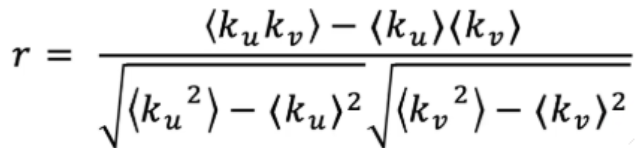

We implement it as a function:

In [61]:
def compute_assortivity_degree(G):
    all_degrees = G.degree()
    deg_u = []
    deg_v = []
    deg_usquared = []
    deg_vsquared = []
    deg_uv = []
    for edge in G.edges():
        nodeu, nodev = edge
        degu = all_degrees[nodeu]
        degv = all_degrees[nodev]

        deg_u.append(degu)
        deg_v.append(degv)
        deg_uv.append(degu*degv)

        deg_usquared.append(degu**2)
        deg_vsquared.append(degv**2)

    mean_degu = np.mean(deg_u)
    mean_degv = np.mean(deg_v)
    mean_deguv = np.mean(deg_uv)
    mean_degusquared = np.mean(deg_usquared)
    mean_degvsquared = np.mean(deg_vsquared)

    tæller = mean_deguv-mean_degu*mean_degv
    nævner = np.sqrt(mean_degusquared-mean_degu**2)*np.sqrt(mean_degvsquared-mean_degv**2)
    r = tæller/nævner
    print(f"The assortativity degree wrt. degree is {r}")
    return r

In [62]:
degree_assortativity_G = compute_assortivity_degree(G)

The assortativity degree wrt. degree is 0.015356397342136858



> 6. *Compare your network's degree assortativity* against that of 100 random networks generated via the configuration model. Analyze whether your network shows a tendency for high-degree scientists to connect with other high-degree scientists and vice versa. 
>



In [ ]:
import matplotlib.pyplot as plt
degree_assortivities = [] 
for graph in configs: 
    degree_assortivities.append(compute_assortivity_degree(graph))

plt.figure()
plt.hist([[degree_assortativity_G],degree_assortivities], bins=30, stacked=True, range=(-1, 1),edgecolor='black')
plt.xlabel("Assortativity")
plt.ylabel("Frequency")
plt.title("Degree assortativity across 100 configuration models")
plt.legend(["CSS Network", "Random Network"])
plt.show()

High-degree scientists tend to connect with low-degree scientists and vice versa. (Mere forklaring baseret på specifik teori fx):
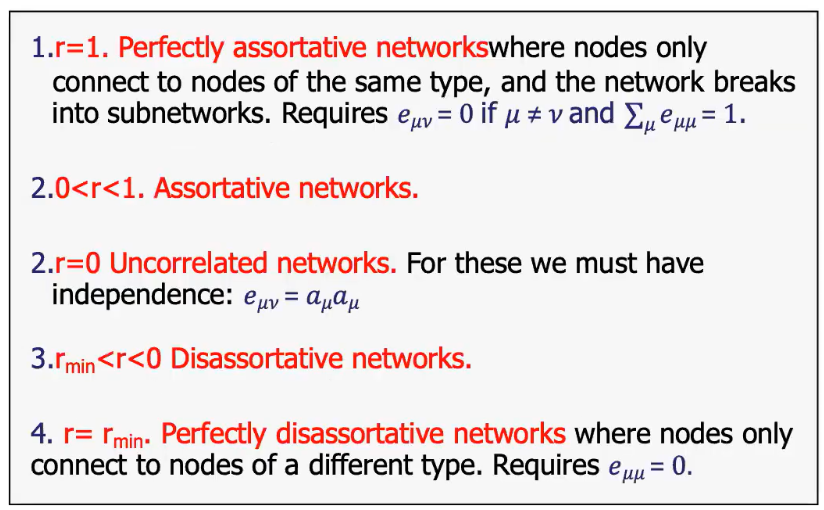

> __Part 5: Reflection questions__    
> 7. *Assortativity by degree.* Were the results of the degree assortativity in line with your expectations? Why or why not?    
> 8. *Edge flipping.* In the process of implementing the configuration model, you were instructed to flip the edges (e.g., changing $e_1$ from (u,v) to (v,u)) 50% of the time. Why do you think this step is included?    
> 9. *Distribution of assortativity in random networks.* Describe the distribution of degree assortativity values you observed for the random 
networks. Was the distribution pattern expected? Discuss how the nature of random network generation (specifically, the configuration model and edge flipping) might influence this distribution and whether it aligns with theoretical expectations.    


MANGLER

# Part 2: TF-IDF

> __Exercise 1: TF-IDF and the Computational Social Science communities.__ The goal for this exercise is to find the words charachterizing each of the communities of Computational Social Scientists.
> What you need for this exercise: 
>.   
>    * The assignment of each author to their network community, and the degree of each author (Week 6, Exercise 4). This can be stored in a dataframe or in two dictionaries, as you prefer.  
>    * the tokenized _abstract_ dataframe (Week 7, Exercise 2)
>

We first assign each author to their network community.

Compute the best partition using the Louvain-algorithm

In [3]:
import community as community_louvain
# compute the best partition
partition_louvain = community_louvain.best_partition(G)
partition_louvain;

Save author group assignments to a dictionary:

In [6]:
communities = {}
for node,data in G.nodes(data=True):
    communities[node] = partition_louvain[node]
communities;

Save the author degrees to a dictionary:

In [25]:
degrees = {}
for node, degree in G.degree():
    degrees[node] = degree
degrees;

The tokenized abstract dataframe from week 7, exercise 7 is loaded:

In [9]:
df_abstracts = pd.read_csv(r"data\Abstracts_token_collocations.csv")

> 1. First, check out [the wikipedia page for TF-IDF](https://en.wikipedia.org/wiki/Tf%E2%80%93idf). Explain in your own words the point of TF-IDF. 
>   * What does TF stand for? 
>   * What does IDF stand for?

TF stands for Term Frequency and measures the frequency of the term in the specific document.

IDF stands for Inverse Document Frequency and is a measure of how often the term appears across all documents in the corpus. This is a measure of how much information the term carries, i.e. more information if the term is less frequent in the corpus.

Finally, the TF-IDF is the product of TF and IDF such that the term frequency is adjusted according to the information carried by the word. This means that a very common word in a document will not recieve a high TF-IDF score if it is also very common in the rest of the corpus. TF-IDF thus measures how important a term is to the particular document.


> 2. Now, we want to find out which words are important for each *community*, so we're going to create several ***large documents, one for each community***. Each document includes all the tokens of abstracts written by members of a given community. 
>   * Consider a community _c_
>   * Find all the abstracts of papers written by a member of community _c_.
>   * Create a long array that stores all the abstract tokens 
>   * Repeat for all the communities. 
> __Note:__ Here, to ensure your code is efficient, you shall exploit ``pandas`` builtin functions, such as [``groupby.apply``](https://pandas.pydata.org/docs/reference/api/pandas.api.typing.DataFrameGroupBy.apply.html) or [``explode``](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html).


First we observe abstracts dataframe:

In [10]:
df_abstracts

,id,title,abstract_inverted_index,text,tokens
0,https://openalex.org/W2999225051,Joint Task Offloading and Resource Allocation ...,"{'Mobile': [0], 'edge': [1, 94], 'computing': ...",Mobile edge computing (MEC) is an emerging tec...,"['mobile_edge', 'computing_mec', 'emerging_tec..."
1,https://openalex.org/W2935719450,Big Data from the South(s): Beyond Data Univer...,"{'This': [0], 'article': [1], 'introduces': [2...",This article introduces the tenets of a theory...,"['article_introduces', 'tenets', 'theory', 'da..."
2,https://openalex.org/W4389636360,Can Large Language Models Transform Computatio...,"{'Abstract': [0], 'Large': [1], 'language': [2...",Abstract Large language models (LLMs) are capa...,"['abstract', 'large_language', 'models_llms', ..."
3,https://openalex.org/W2806983856,On the Origins of Memes by Means of Fringe Web...,"{'Internet': [0], 'memes': [1, 35, 127, 138, 1...",Internet memes are increasingly used to sway a...,"['internet', 'memes', 'increasingly_used', 'sw..."
4,https://openalex.org/W2115022330,Measurement and analysis of online social netw...,"{'Online': [0], 'social': [1, 24, 53, 76], 'ne...","Online social networking sites like Orkut, You...","['online_social', 'networking_sites', 'like', ..."
...,...,...,...,...,...
152324,https://openalex.org/W2971743178,Video Quality Adaptation for Limiting Transcod...,"{'Dynamic': [0], 'adaptive': [1], 'streaming':...",Dynamic adaptive streaming over HTTP (DASH) in...,"['dynamic', 'adaptive', 'streaming', 'http', '..."
152325,https://openalex.org/W3008208901,Deep Image Spatial Transformation for Person I...,"{'Pose-guided': [0], 'person': [1, 9], 'image'...",Pose-guided person image generation is to tran...,"['poseguided', 'person', 'image_generation', '..."
152326,https://openalex.org/W2552329007,Non-Orthogonal Multiple Access in Multi-Cell N...,"{'Non-orthogonal': [0], 'multiple': [1, 19, 48...",Non-orthogonal multiple access (NOMA) is a pot...,"['nonorthogonal', 'multiple', 'access', 'noma'..."
152327,https://openalex.org/W3083515752,Respect for Human Autonomy in Recommender Systems,"{'Recommender': [0], 'systems': [1, 20, 31, 14...",Recommender systems can influence human behavi...,"['recommender_systems', 'influence_human', 'be..."


The problem is that this dataframe does not contain the author ids (only the work id), so we can't look up which community each author belongs to. 

Thus we merge the abstracts dataframe with the paper dataframe which contains both the author ids and the work id:

In [14]:
# left outer join
import ast
df_abstracts = pd.merge(df_abstracts, CSS_papers, on='id', how='left')
df_abstracts['author_ids'] = df_abstracts['author_ids'].apply(ast.literal_eval) # Make string to dict
df_abstracts = df_abstracts.explode("author_ids")
df_abstracts= df_abstracts.dropna() 
df_abstracts

,id,title,abstract_inverted_index,text,tokens,publication_year,cited_by_count,author_ids
0,https://openalex.org/W2999225051,Joint Task Offloading and Resource Allocation ...,"{'Mobile': [0], 'edge': [1, 94], 'computing': ...",Mobile edge computing (MEC) is an emerging tec...,"['mobile_edge', 'computing_mec', 'emerging_tec...",2020.0,466,https://openalex.org/A5049211438
0,https://openalex.org/W2999225051,Joint Task Offloading and Resource Allocation ...,"{'Mobile': [0], 'edge': [1, 94], 'computing': ...",Mobile edge computing (MEC) is an emerging tec...,"['mobile_edge', 'computing_mec', 'emerging_tec...",2020.0,466,https://openalex.org/A5035287134
0,https://openalex.org/W2999225051,Joint Task Offloading and Resource Allocation ...,"{'Mobile': [0], 'edge': [1, 94], 'computing': ...",Mobile edge computing (MEC) is an emerging tec...,"['mobile_edge', 'computing_mec', 'emerging_tec...",2020.0,466,https://openalex.org/A5042460024
0,https://openalex.org/W2999225051,Joint Task Offloading and Resource Allocation ...,"{'Mobile': [0], 'edge': [1, 94], 'computing': ...",Mobile edge computing (MEC) is an emerging tec...,"['mobile_edge', 'computing_mec', 'emerging_tec...",2020.0,466,https://openalex.org/A5081180851
1,https://openalex.org/W2935719450,Big Data from the South(s): Beyond Data Univer...,"{'This': [0], 'article': [1], 'introduces': [2...",This article introduces the tenets of a theory...,"['article_introduces', 'tenets', 'theory', 'da...",2019.0,390,https://openalex.org/A5017799138
...,...,...,...,...,...,...,...,...
152326,https://openalex.org/W2552329007,Non-Orthogonal Multiple Access in Multi-Cell N...,"{'Non-orthogonal': [0], 'multiple': [1, 19, 48...",Non-orthogonal multiple access (NOMA) is a pot...,"['nonorthogonal', 'multiple', 'access', 'noma'...",2016.0,24,https://openalex.org/A5100376261
152326,https://openalex.org/W2552329007,Non-Orthogonal Multiple Access in Multi-Cell N...,"{'Non-orthogonal': [0], 'multiple': [1, 19, 48...",Non-orthogonal multiple access (NOMA) is a pot...,"['nonorthogonal', 'multiple', 'access', 'noma'...",2016.0,24,https://openalex.org/A5042307561
152327,https://openalex.org/W3083515752,Respect for Human Autonomy in Recommender Systems,"{'Recommender': [0], 'systems': [1, 20, 31, 14...",Recommender systems can influence human behavi...,"['recommender_systems', 'influence_human', 'be...",2020.0,21,https://openalex.org/A5065423139
152328,https://openalex.org/W2133895365,Joint optimization of frame type selection and...,"{'In': [0, 22], 'this': [1, 23], 'paper,': [2]...","In this paper, we present an algorithm for joi...","['paper', 'present', 'algorithm', 'joint', 'op...",2002.0,19,https://openalex.org/A5100376261


As seen above, we have also utilized the explode function to make sure each row only contains 1 author.

Now we can get the abstracts and authors for each community:

In [15]:
from collections import defaultdict
community_abstracts = defaultdict(list)
community_authors = defaultdict(list)

# Få abstracts og authors for hver community
def community_abstracts_func(row):
    id = row["author_ids"]
    abstract = row["tokens"]
    try:
        community = int(communities[id])
    except: # Error when trying to find the author ID in communities, but it does not exist
        pass 
    else:
        community_abstracts[community].append(abstract)
        community_authors[community].append(id)
df_abstracts.apply(community_abstracts_func, axis=1);

Above, we have made a try-except because all authors in G are from the original CSS authors and thus the community graph only contain these authors. Thus, a lot of authors in the abstracts and papers dataset does not exist in the community graph, which will cause an error.

We get two dictionaries with all the communities as keys and either the authors or abstracts belonging to that community as values.

To make a long array that stores all the abstracts for each community, we extract from the nested abstracts:

In [16]:
# Take nested abstracts and convert to one array for each community
community_abstracts_nested = {}
for community, abstracts in community_abstracts.items():
    all_tokens = []
    for abstract_str in abstracts:
        abstract_tokens = ast.literal_eval(abstract_str)
        all_tokens.extend(abstract_tokens)
    community_abstracts_nested[community] = all_tokens

community_abstracts_nested

{17: ['mobile_edge',
  'computing_mec',
  'emerging_technology',
  'support',
  'resourceintensive',
  'yet',
  'delaysensitive',
  'applications_using',
  'small',
  'cloudcomputing',
  'platforms',
  'deployed',
  'mobile_network',
  'edges',
  'however',
  'existing',
  'mec',
  'techniques',
  'applicable',
  'situation',
  'number',
  'mobile_users',
  'increases',
  'explosively',
  'network',
  'facilities',
  'sparely',
  'distributed',
  'view',
  'insufficiency',
  'unmanned_aerial',
  'vehicles',
  'uavs',
  'employed',
  'improve',
  'connectivity',
  'ground',
  'internet',
  'things_iot',
  'devices',
  'due',
  'high',
  'altitude',
  'article_proposes',
  'innovative',
  'uavenabled',
  'mec',
  'system',
  'involving',
  'interactions_among',
  'iot_devices',
  'uav',
  'edge',
  'clouds',
  'ecs',
  'system',
  'deploys',
  'operates',
  'uav',
  'properly',
  'facilitate',
  'mec',
  'service_provisioning',
  'set',
  'iot_devices',
  'regions',
  'existing',
  'ecs'

> 3. Now, we're ready to calculate the TF for each word. Use the method of your choice to find the top 5 terms within the __top 5 communities__ (by number of authors). 


First we find the amount of authors for each community:

In [17]:
# Get amount of authors per community
number_of_authors_in_community = {}
for community,authors in community_authors.items():
    number_of_authors_in_community[community] = len(set(authors))

Now we sort the communities by the amount of authors and extract the top 5:

In [18]:
top_communities_authors = {k: v for k, v in sorted(number_of_authors_in_community.items(), key=lambda item: item[1], reverse=True)}
top_5_communities = list(top_communities_authors.keys())[0:5]
f"The top 5 communities in terms of amount of authors are {top_5_communities}"

'The top 5 communities in terms of amount of authors are [11, 34, 10, 43, 21]'

Now we calculate the TF for the top 5 communities and find the top 5 terms:

In [19]:
tf_top5 = {}
for community in top_5_communities:
    tokens = community_abstracts_nested[community]
    total_tokens = len(tokens)
    
    # Count word frequencies
    word_freq = defaultdict(int)
    for token in tokens:
        word_freq[token] += 1
    
    # Calculate TF (frequency / total)
    tf = {word: freq / total_tokens for word, freq in word_freq.items()}
    
    # Get top 5 terms
    top_5_terms = sorted(tf.items(), key=lambda x: x[1], reverse=True)[:5]
    
    tf_top5[community] = tf
    
    print(f"\nCommunity {community} - Top 5 TF terms:")
    for term, tf_score in top_5_terms:
        print(f"  {term}: {tf_score:.4f}")


Community 11 - Top 5 TF terms:
  users: 0.0038
  use: 0.0034
  work: 0.0030
  data: 0.0029
  design: 0.0029

Community 34 - Top 5 TF terms:
  model: 0.0031
  information: 0.0026
  participants: 0.0025
  models: 0.0024
  learning: 0.0022

Community 10 - Top 5 TF terms:
  study: 0.0038
  participants: 0.0031
  people: 0.0030
  research: 0.0029
  group: 0.0028

Community 43 - Top 5 TF terms:
  model: 0.0034
  show: 0.0034
  data: 0.0028
  use: 0.0024
  using: 0.0023

Community 21 - Top 5 TF terms:
  model: 0.0045
  network: 0.0039
  networks: 0.0037
  find: 0.0033
  study: 0.0032


>   * Describe similarities and differences between the communities.
>   * Why aren't the TFs not necessarily a good description of the communities?

We see that community 21 has mentions of networks, which none of the other communities show. Furthermore, community 43 and 11 have the word data. The communities all mention things such as study, participants, model. This is general language within the field, which makes it hard to distinguish the communities as these 'generic' words take over because they are used in most abstracts in the community. The term frequency is not a good description, because the informative or rare words are drowning in the less important but common words. 

>   * Next, we calculate IDF for every word. 

In [20]:
import numpy as np
word_doc_count = defaultdict(int)
total_docs = 0

# Global IDF across all the 5 communities
for community in top_5_communities:
    total_docs += len(community_abstracts[community])
    tokens = community_abstracts_nested[community]
    unique_words = set(tokens)
    for word in unique_words:
        word_doc_count[word] += 1
    
# Calculate IDF for each word
idfs = {word: np.log(total_docs / doc_count) 
        for word, doc_count in word_doc_count.items()}
idfs

{'low_quality': np.float64(9.023769800892813),
 'preferably': np.float64(9.246913352207024),
 'irvineview': np.float64(10.633207713326913),
 'also_identify': np.float64(9.023769800892813),
 'unconstrained': np.float64(9.023769800892813),
 'sensorimotor': np.float64(9.023769800892813),
 'forcetomotion': np.float64(10.633207713326913),
 'led_us': np.float64(9.023769800892813),
 'turn': np.float64(9.023769800892813),
 'model_describes': np.float64(9.023769800892813),
 'timescheck': np.float64(10.633207713326913),
 'contractors': np.float64(9.246913352207024),
 'might_better': np.float64(9.246913352207024),
 'entire_population': np.float64(9.534595424658804),
 'innovated': np.float64(10.633207713326913),
 'ampquotfacsampquot': np.float64(10.633207713326913),
 'alliances': np.float64(9.023769800892813),
 'selves': np.float64(9.246913352207024),
 'megasites': np.float64(10.633207713326913),
 'discouragedsuccessful': np.float64(10.633207713326913),
 'nightscoutan': np.float64(10.6332077133269

>   * What base logarithm did you use? Is that important?

We have used the natural logarithm. The base of the logarithm does not matter, as it simply changes the scale of the IDF scores. Because the same logarithm is applied to all terms, it does not change the order of term scores, and the terms with the largest scores will not change with a different base. 

> 4. We're ready to calculate TF-IDF. Do that for the __top 9 communities__ (by number of authors). Then for each community: 
>   * List the 10 top TF words 
>   * List the 10 top TF-IDF words
>   * List the top 3 authors (by degree)


Find the top 9 communities:

In [22]:
top_9_communities = list(top_communities_authors.keys())[0:9]
f"The top 9 communities in terms of amount of authors are {top_9_communities}"

'The top 9 communities in terms of amount of authors are [11, 34, 10, 43, 21, 19, 48, 16, 12]'

In [35]:
import numpy as np
from collections import defaultdict
ALL_communities=top_communities_authors.keys()

# Calculate GLOBAL IDF across ALL TOP 9 communities
word_doc_count = defaultdict(int)
total_docs = 0

for community in top_9_communities:
    total_docs += len(community_abstracts[community])
    tokens = community_abstracts_nested[community]
    unique_words = set(tokens)
    for word in unique_words:
        word_doc_count[word] += 1

# Calculate IDF for each word (across all communities)
idfs = {word: np.log(total_docs / doc_count) 
        for word, doc_count in word_doc_count.items()}

# Now calculate TF and TF-IDF for the top 9 communities using these IDF values
tfidf_results = {}

for community in top_9_communities:
    tokens = community_abstracts_nested[community]
    total_tokens = len(tokens)
    
    # Calculate TF
    word_freq = defaultdict(int)
    for token in tokens:
        word_freq[token] += 1
    
    tf_scores = {word: freq / total_tokens for word, freq in word_freq.items()}
    
    # Calculate TF-IDF
    tfidf_scores = {word: tf_scores[word] * idfs.get(word, 0) 
                    for word in tf_scores}
    
    tfidf_results[community] = {
        'tf': tf_scores,
        'tfidf': tfidf_scores
    }

In [36]:
# Display results for each community
top_authors_by_community = defaultdict(list)
for community in top_9_communities:
    print(f"\n{'='*70}")
    print(f"COMMUNITY {community} ({len(community_abstracts[community])} papers)")
    print(f"{'='*70}")
    
    # Top 10 TF words
    top_tf = sorted(tfidf_results[community]['tf'].items(), key=lambda x: x[1], reverse=True)[:10] 
    print("\nTop 10 TF words:")
    for i, (word, tf_score) in enumerate(top_tf, 1):
        print(f"  {i:2d}. {word:25s} {tf_score:.6f}")
    
    # Top 10 TF-IDF words
    top_tfidf = sorted(tfidf_results[community]['tfidf'].items(), key=lambda x: x[1], reverse=True)[:10]
    print("\nTop 10 TF-IDF words:")
    for i, (word, tfidf_score) in enumerate(top_tfidf, 1):
        print(f"  {i:2d}. {word:25s} {tfidf_score:.6f}")
    
    # Top 3 authors by degree
    print("\nTop 3 authors (by degree):")
    comm_authors = community_authors[community]
    author_degrees = {}
    for author in comm_authors:
        if author in degrees:
            author_degrees[author] = degrees[author]
    
    top_authors = sorted(author_degrees.items(), key=lambda x: x[1], reverse=True)[:3]
    for i, (author, degree) in enumerate(top_authors, 1):
        print(f"  {i}. Author {author}: degree {degree}")
        top_authors_by_community[community].append(author)


COMMUNITY 11 (9367 papers)

Top 10 TF words:
   1. users                     0.003763
   2. use                       0.003448
   3. work                      0.003030
   4. data                      0.002926
   5. design                    0.002889
   6. using                     0.002739
   7. paper                     0.002676
   8. students                  0.002636
   9. model                     0.002566
  10. study                     0.002491

Top 10 TF-IDF words:
   1. users                     0.033294
   2. use                       0.030505
   3. work                      0.026808
   4. data                      0.025890
   5. design                    0.025554
   6. using                     0.024236
   7. paper                     0.023674
   8. students                  0.023317
   9. model                     0.022701
  10. study                     0.022041

Top 3 authors (by degree):
  1. Author https://openalex.org/A5076189854: degree 154
  2. Author https://openale

>   * Are these 10 words more descriptive of the community? If yes, what is it about IDF that makes the words more informative?

MANGLER

Åh nej. Her får vi altså et problem, fordi vores idf scores kun kan antage ni værdier fordi vi kun har ni dokumenter nu. Det betyder, at alle de ord, der kun appear i et community har samme idf score, og vi lader TF overtage???

In [34]:
sorted(idfs.items(),key=lambda item:item[1])[:20]

[('using', np.float64(6.81422684426023)),
 ('study', np.float64(6.829494316391019)),
 ('data', np.float64(6.860746859895123)),
 ('results', np.float64(6.871385258100179)),
 ('however', np.float64(6.876747201241564)),
 ('different', np.float64(6.88213804987644)),
 ('use', np.float64(6.88213804987644)),
 ('model', np.float64(6.88755811734578)),
 ('used', np.float64(6.893007722113344)),
 ('based', np.float64(6.89848718787797)),
 ('also', np.float64(6.9151080691140105)),
 ('analysis', np.float64(6.92071032466268)),
 ('well', np.float64(6.937707901031251)),
 ('one', np.float64(6.943438575740236)),
 ('first', np.float64(6.954999398141313)),
 ('paper', np.float64(6.954999398141313)),
 ('abstract', np.float64(6.966695437904503)),
 ('show', np.float64(6.972595160031692)),
 ('time', np.float64(6.98450006253801)),
 ('research', np.float64(6.996548401054184))]

 __Exercise 2: The Wordcloud__. It's time to visualize our results!

> * Install the [`WordCloud`](https://pypi.org/project/wordcloud/) module. 
> * Now, create word-cloud for each community. Feel free to make it as fancy or non-fancy as you like.
> * Make sure that, together with the word cloud, you print the names of the top three authors in each community (see my plot above for inspiration). 


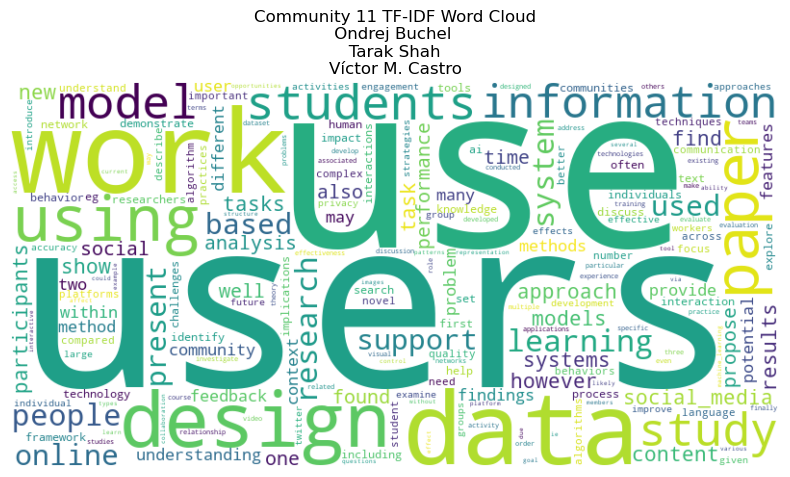

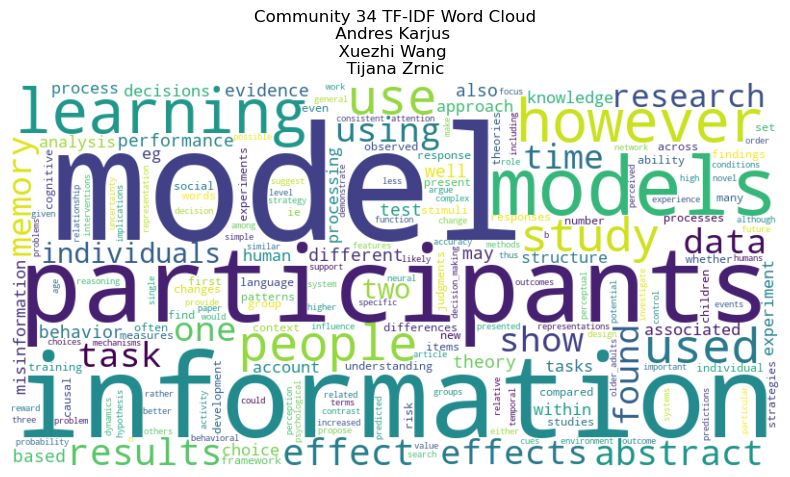

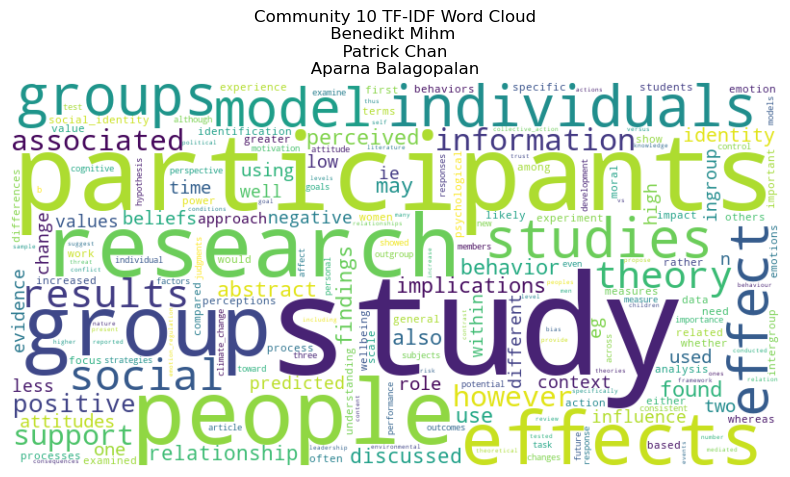

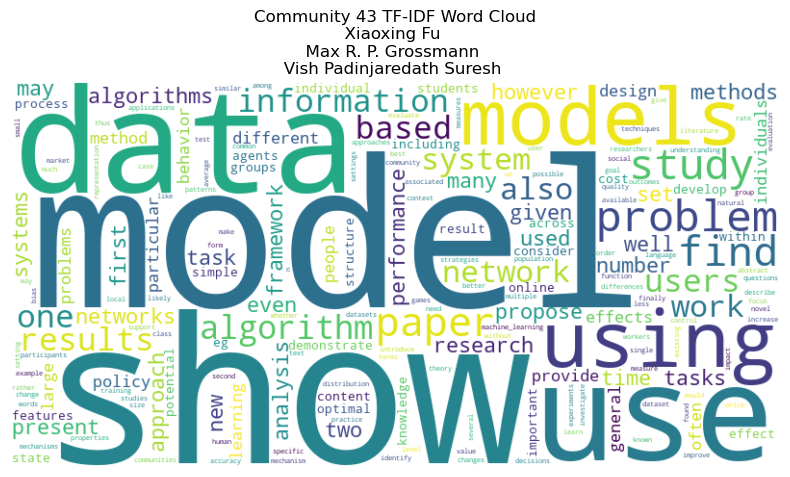

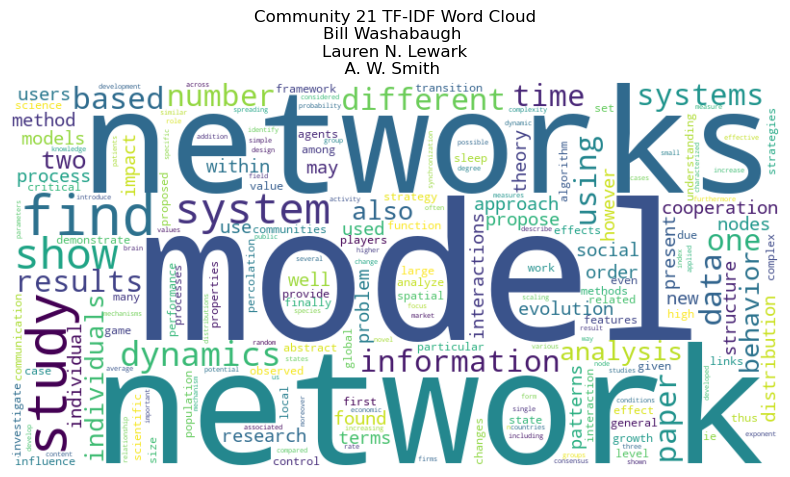

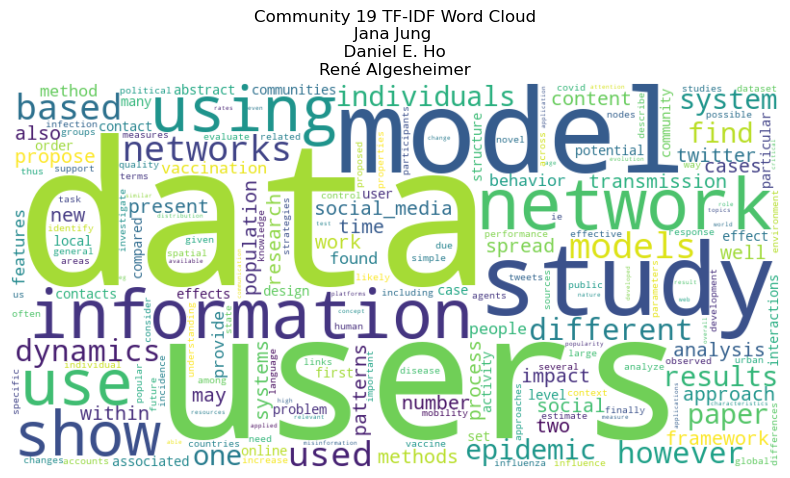

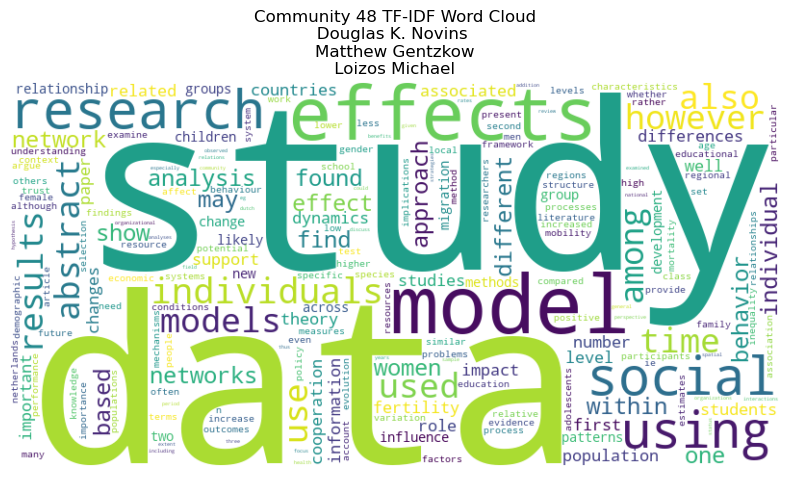

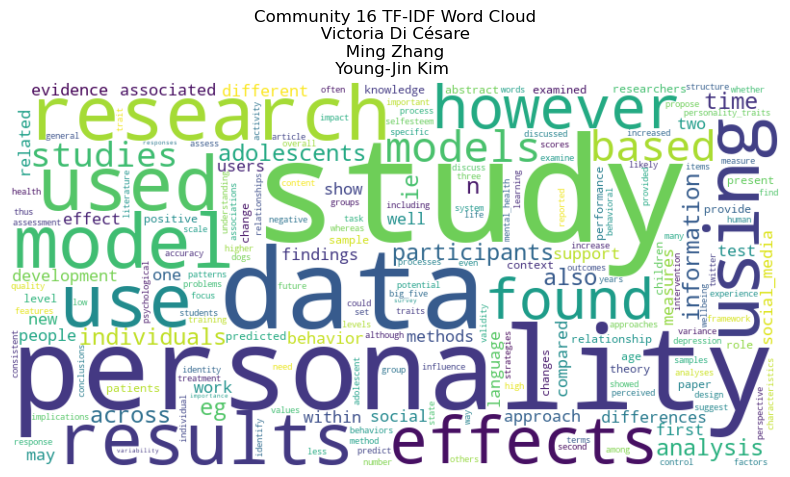

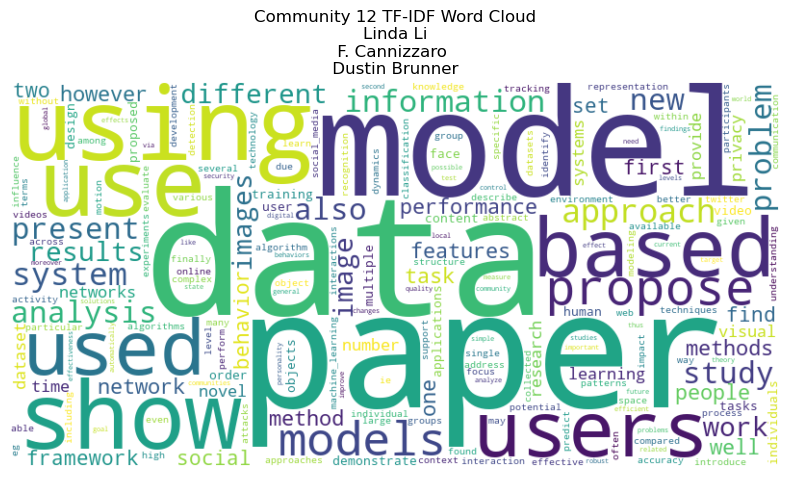

In [37]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for community in top_9_communities:
    # Use TF-IDF scores to weight words in word cloud
    tfidf_dict = tfidf_results[community]['tfidf']
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(tfidf_dict)

    # Top 3 authors of that community
    top_3_authors = top_authors_by_community[community]

    # Find display name of the top 3 authors
    name_lines = []
    for author in top_3_authors:
        display_name = G.nodes[author]["display_name"]
        name_lines.append(f"{display_name:^40}")  # center within 40 chars

    title_text = f"Community {community} TF-IDF Word Cloud\n" + "\n".join(name_lines)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title_text)
    plt.show()

> * Comment on your results. What can you conclude on the different sub-communities in Computational Social Science? 
> * Look up online the top author in each community. In light of your search, do your results make sense?

MANGLER

 __Exercise 3: Computational Social Science__ 

> * In light of your data-driven analysis, has your understanding of the field changed? How? 

MANGLER